In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 사용 함수

In [3]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

# 데이터 로드

In [4]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("transcript_portfolio_profile.csv")

# 테이블 복제
# informational은 completed 개념이 없으니 제거하고 시작
# 필요시 그냥 df2 = df.copy() 사용
df2 = df[df['offer_type'] != 'informational'].copy()
# df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,280071
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,11.85,246889,88.15,4
amount,float64,138953,49.61,141118,50.39,5103
offer_id,str,141118,50.39,138953,49.61,8
offer_reward,float64,141118,50.39,138953,49.61,4
difficulty,float64,141118,50.39,138953,49.61,4
channels,str,141118,50.39,138953,49.61,4
duration,float64,141118,50.39,138953,49.61,3
offer_type,str,141118,50.39,138953,49.61,2
web,float64,141118,50.39,138953,49.61,2
mobile,float64,141118,50.39,138953,49.61,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


전환율 기준 = completed / received\
단, duration 안에서 일어난 completed만 인정

시간 순서를 고려해\
고객 세그먼트, reward, difficulty, channel, offer_type 같은 변수와 붙여 분석

# received / completed 이벤트 분리
전환율의 분모와 분자 생성

In [5]:
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("completed 행 수:", len(completed))

received 행 수: 61042
completed 행 수: 33182


# 시간순 정렬
customer_id + offer_id 기준으로 시간순 번호를 붙여 맞추기

원래 seq 방식으로 n번째 received와 n번째 completed를 연결하고자 했으나\
같은 고객이 같은 오퍼를 이전 오퍼 유효기간이 끝나기 전에 또 받은 경우 문제가 발생할수도 있어 변경

completed보다 먼저 온 received만 후보로 보고, 그중 가장 최근 received를 연결하는 구조로 변경

코드 실행 시간이 매우 깁니다. (대략 10분)

In [6]:
# ============================================================
# completed를 가장 최근의 유효한 received에 연결
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 행 번호 만들기
received["received_idx"] = received.index

In [7]:
match_rows = []

# customer_id + offer_id 기준으로 completed를 하나씩 확인
for (customer_id, offer_id), completed_group in completed.groupby(["customer_id", "offer_id"]):
    
    # 같은 customer_id, offer_id의 received만 따로 가져오기
    received_group = received[
        (received["customer_id"] == customer_id) &
        (received["offer_id"] == offer_id)
    ].copy()
    
    # 이미 매칭된 received는 다시 쓰지 않기 위한 집합
    used_received = set()
    
    # completed 시간만 하나씩 확인
    for completed_time in completed_group["time_completed"]:
        
        # 조건에 맞는 received 후보 찾기
        candidates = received_group[
            (received_group["time_received"] <= completed_time) &
            ((completed_time - received_group["time_received"]) <= received_group["duration"] * 24) &
            (~received_group["received_idx"].isin(used_received))
        ].copy()
        
        # 후보가 없으면 다음 completed로
        if len(candidates) == 0:
            continue
        
        # 후보 중 가장 최근 received 선택
        best_received = candidates.sort_values("time_received", ascending=False).iloc[0]
        
        # 매칭 결과 저장
        match_rows.append({
            "received_idx": best_received["received_idx"],
            "time_completed": completed_time
        })
        
        # 사용한 received는 다시 못 쓰게 저장
        used_received.add(best_received["received_idx"])

# 매칭 결과 테이블
match_df = pd.DataFrame(match_rows)

# 최종 전환 컬럼 생성
received와 completed 연결

In [8]:
rc = received.merge(
    match_df,
    on="received_idx",
    how='left'
)

rc["has_completed"] = rc["time_completed"].notna().astype(int)
rc["time_diff"] = rc["time_completed"] - rc["time_received"]

rc["valid_time_order"] = (
    (rc["time_diff"] >= 0)
).fillna(False).astype(int)

rc["valid_duration"] = (
    (rc["time_diff"] >= 0) &
    (rc["time_diff"] <= rc["duration"] * 24)
).fillna(False).astype(int)

rc["converted_final"] = (
    (rc["has_completed"] == 1) &
    (rc["valid_time_order"] == 1) &
    (rc["valid_duration"] == 1)
).astype(int)

rc = rc[
    [
        # 1. 고객 / 오퍼 식별
        'customer_id', 'offer_id',

        # 2. 오퍼 속성
        'offer_type', 'offer_reward', 'difficulty', 'duration',

        # 3. 채널 정보
        'web', 'email', 'mobile', 'social',

        # 4. 시간 정보
        'time_received', 'time_completed', 'time_diff',

        # 5. 판정 결과
        'has_completed', 'valid_time_order', 'valid_duration', 'converted_final'
    ]
].copy()

check_basic_info(rc, 'received + completed ')


received + completed 의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,61042
1,열 개수,17
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed,float64,33152,54.31,27890,45.69,120
time_diff,float64,33152,54.31,27890,45.69,41
customer_id,str,61042,100.00,0,0.00,16928
offer_id,str,61042,100.00,0,0.00,8
time_received,int64,61042,100.00,0,0.00,6
offer_reward,float64,61042,100.00,0,0.00,4
difficulty,float64,61042,100.00,0,0.00,4
duration,float64,61042,100.00,0,0.00,3
offer_type,str,61042,100.00,0,0.00,2
web,float64,61042,100.00,0,0.00,2


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,time_completed,time_diff,has_completed,valid_time_order,valid_duration,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,576.0,0.0,1,1,1,1
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,414.0,6.0,1,1,1,1
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,528.0,24.0,1,1,1,1
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,168,NaN,NaN,0,0,0,0
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,576,NaN,NaN,0,0,0,0


# 완성물 해설
offer received를 기준으로 offer completed를 연결해,\
최종적으로 **유효한 전환인지 아닌지**를 판단하기 위한 매칭 테이블

추가된 컬럼 설명
| 컬럼명                | 설명                                      |
| ------------------ | --------------------------------------- |
| `time_completed`   | 연결된 오퍼 완료 시점(hour 기준)                   |
| `has_completed`    | 해당 received에 대응되는 completed가 존재하는지 여부   |
| `time_diff`        | 오퍼 수신 시점부터 완료 시점까지의 시간 차이               |
| `valid_time_order` | completed가 received 이후 발생했는지 여부         |
| `valid_duration`   | completed가 오퍼 유효기간 내에 발생했는지 여부          |
| `converted_final`  | 시간 순서와 기간 조건을 모두 만족하는 최종 전환 여부          |


converted_final (1 = 최종 전환 인정, 0 = 최종 전환 미인정)\
completed 존재 여부\
시간 순서 적절성\
duration 내 완료 여부\
를 반영한 판정 결과


time_completed 결측치 = 미완료 received \
이 received 건에 대응되는 completed가 없음

time_diff 결측치 = 완료 시간이 없어서 계산 불가\
time_completed - time_received를 계산할 수 없음\
time_completed 자체가 비어 있어서



# 검증단계

In [9]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

print("received 기준 전체 건수:", len(rc))
print("completed가 붙은 건수:", rc['has_completed'].sum())
print("타임 순서가 맞는 건수:", rc['valid_time_order'].sum())
print("duration 안에 완료된 건수:", rc['valid_duration'].sum())
print("최종 전환 건수:", rc['converted_final'].sum())
print()
print("최종 전환율:", round(rc['converted_final'].mean() * 100, 2), "%")

기본 검증단계
received 기준 전체 건수: 61042
completed가 붙은 건수: 33152
타임 순서가 맞는 건수: 33152
duration 안에 완료된 건수: 33152
최종 전환 건수: 33152

최종 전환율: 54.31 %


In [10]:
offer_type_conv = (
    rc.groupby('offer_type')
      .agg(
          received_count=('customer_id', 'size'),
          converted_count=('converted_final', 'sum'),
          conversion_rate=('converted_final', 'mean')
      )
      .reset_index()
)

offer_type_conv['conversion_rate'] = (offer_type_conv['conversion_rate'] * 100).round(2)

print("=" * 80)
print("오퍼 유형별 최종 전환율")
print("=" * 80)
display(offer_type_conv)

오퍼 유형별 최종 전환율


,offer_type,received_count,converted_count,conversion_rate
0,bogo,30499,15501,50.82
1,discount,30543,17651,57.79


# 주의 

구매 전환율이 아니라 오퍼 유효 완료 전환율임


In [11]:
# ============================================================
# viewed 데이터 분리
# ============================================================
viewed = (
    df2[df2['event'] == 'offer viewed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_viewed'})
)

# 정렬 (안정성)
viewed = viewed.sort_values(
    ["customer_id", "offer_id", "time_viewed"]
).reset_index(drop=True)


# ============================================================
# 각 received 기준으로 viewed 여부 판단
# ============================================================
view_flag_list = []

for idx, row in rc.iterrows():
    
    cust = row['customer_id']
    offer = row['offer_id']
    r_time = row['time_received']
    duration = row['duration'] * 24  # 시간 단위 맞추기
    
    # 해당 고객 + 오퍼의 viewed만 추출
    viewed_group = viewed[
        (viewed['customer_id'] == cust) &
        (viewed['offer_id'] == offer)
    ]
    
    # 유효 기간 내 viewed 존재 여부
    has_viewed = (
        (viewed_group['time_viewed'] >= r_time) &
        (viewed_group['time_viewed'] <= r_time + duration)
    ).any()
    
    view_flag_list.append(int(has_viewed))

# 컬럼 추가
rc['has_viewed'] = view_flag_list


# ============================================================
# 🔥 최종 상태 분류
# ============================================================
def classify_status(row):
    if row['converted_final'] == 1:
        return 'converted'
    elif row['has_viewed'] == 0:
        return 'not_viewed'
    else:
        return 'viewed_not_converted'

rc['status'] = rc.apply(classify_status, axis=1)

In [12]:
print("=" * 80)
print("상태별 개체수 + 비율")
print("=" * 80)

status_summary = (
    rc['status']
    .value_counts()
    .to_frame(name='count')  # 개체수
)

status_summary['ratio(%)'] = (
    status_summary['count'] / len(rc) * 100
).round(2)

display(status_summary)

상태별 개체수 + 비율


,count,ratio(%)
status,,
converted,33152,54.31
viewed_not_converted,19422,31.82
not_viewed,8468,13.87


중도이탈자는 전체의 31%, 전환자 수 대비 약 59% 수준으로 나타났다(viewed->completed로 유도하는 방향 제시)

In [13]:
print("=" * 80)
print("퍼널 구조")
print("=" * 80)

total = len(rc)
viewed = rc['has_viewed'].sum()
converted = rc['converted_final'].sum()

print(f"received: {total}")
print(f"viewed: {viewed} ({viewed/total*100:.2f}%)")
print(f"converted: {converted} ({converted/total*100:.2f}%)")

퍼널 구조
received: 61042
viewed: 46931 (76.88%)
converted: 33152 (54.31%)


In [14]:
offer_status = (
    rc.groupby(['offer_type', 'status'])
      .size()
      .unstack(fill_value=0)
)


print("📊 개체수")
display(offer_status)


📊 개체수


status,converted,not_viewed,viewed_not_converted
offer_type,,,
bogo,15501,2851,12147
discount,17651,5617,7275


<Figure size 1200x600 with 0 Axes>

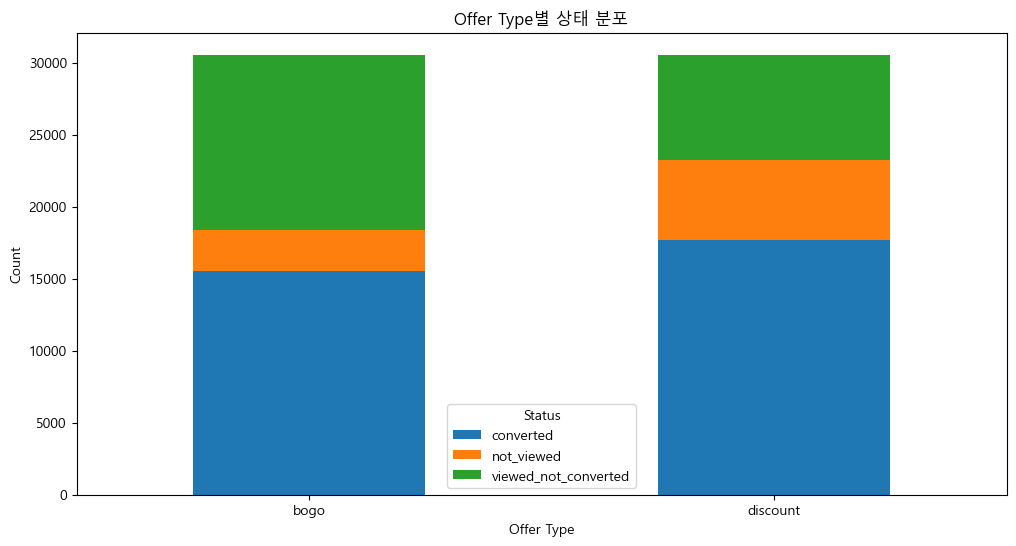

In [15]:
plt.figure()

offer_status = (
    rc.groupby(['offer_type', 'status'])
      .size()
      .unstack(fill_value=0)
)

offer_status.plot(kind='bar', stacked=True)

plt.title('Offer Type별 상태 분포')
plt.xlabel('Offer Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Status')

plt.show()

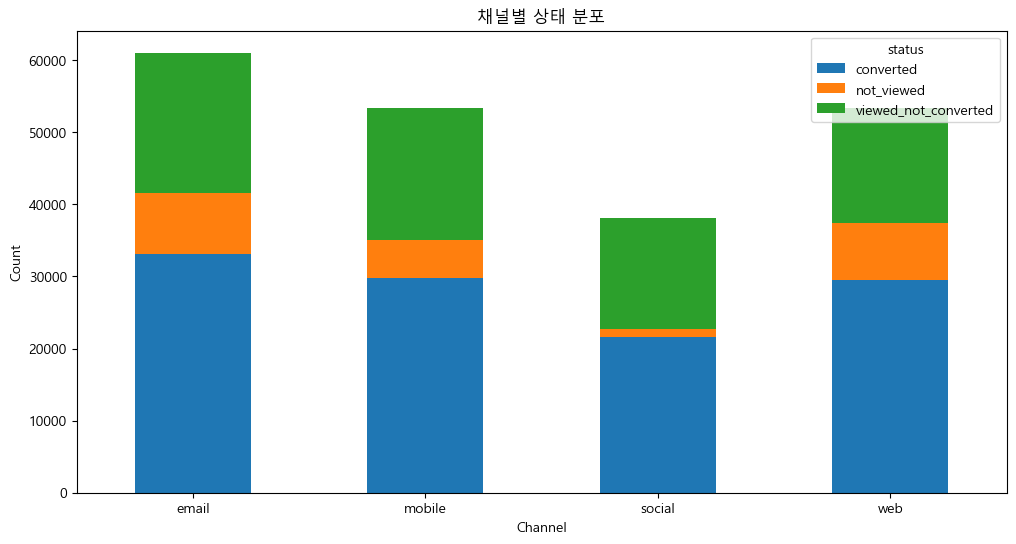

In [16]:
# 채널 펼치기
channel_cols = ['web', 'email', 'mobile', 'social']

channel_df = rc.copy()

channel_long = channel_df.melt(
    id_vars=['status'],
    value_vars=channel_cols,
    var_name='channel',
    value_name='used'
)

# 채널 사용된 것만
channel_long = channel_long[channel_long['used'] == 1]

# 집계
channel_status = (
    channel_long.groupby(['channel', 'status'])
    .size()
    .unstack(fill_value=0)
)

# 시각화
channel_status.plot(kind='bar', stacked=True)

plt.title('채널별 상태 분포')
plt.xlabel('Channel')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

In [17]:
# ============================================================
# 고객 프로필 정보 추출 (중복 제거 필수)
# ============================================================
profile_cols = ['customer_id', 'gender', 'age', 'income']

profile = (
    df[profile_cols]
    .drop_duplicates(subset='customer_id')
)

# ============================================================
# rc에 merge
# ============================================================
rc = rc.merge(profile, on='customer_id', how='left')

In [18]:
rc['age_group'] = pd.cut(
    rc['age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['~20', '20s', '30s', '40s', '50s', '60+']
)

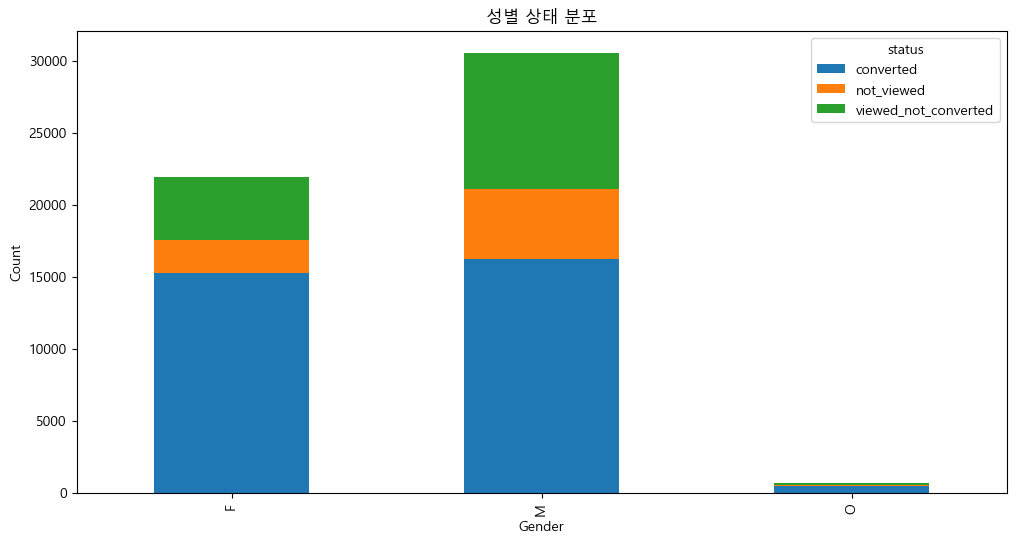

In [19]:
gender_status = (
    rc.groupby(['gender', 'status'])
      .size()
      .unstack(fill_value=0)
)

gender_status.plot(kind='bar', stacked=True)

plt.title('성별 상태 분포')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

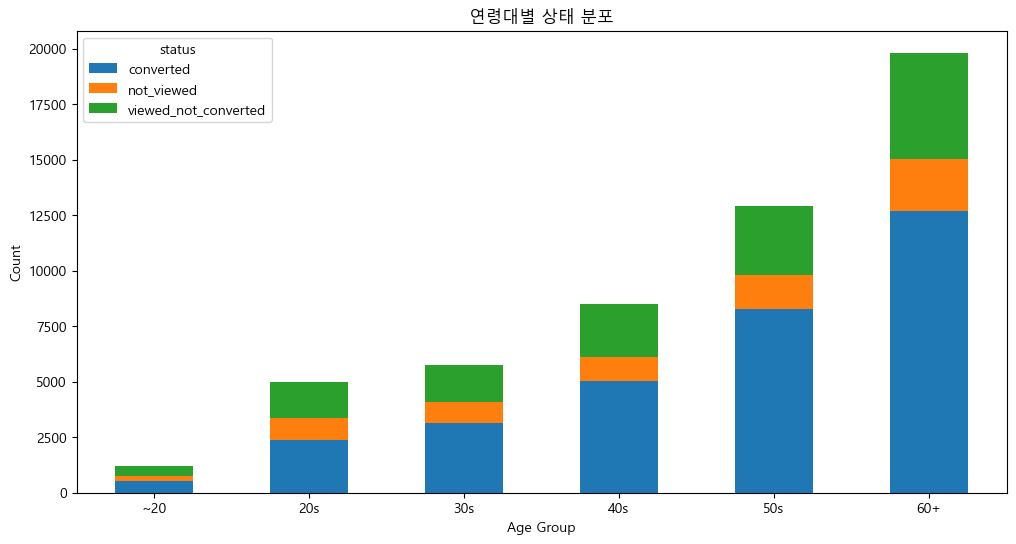

In [20]:
age_status = (
    rc.groupby(['age_group', 'status'])
      .size()
      .unstack(fill_value=0)
)

age_status.plot(kind='bar', stacked=True)

plt.title('연령대별 상태 분포')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

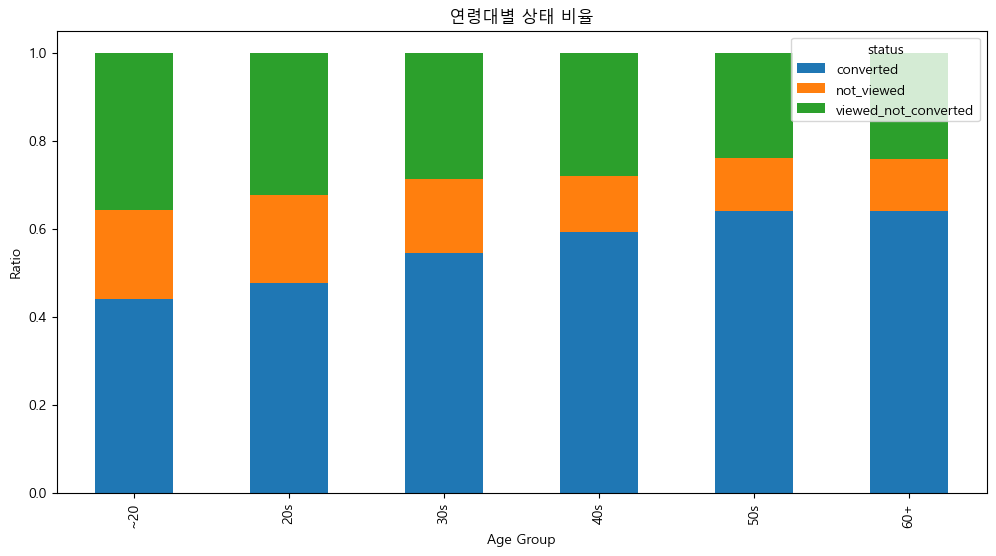

In [21]:
age_ratio = age_status.div(age_status.sum(axis=1), axis=0)

age_ratio.plot(kind='bar', stacked=True)

plt.title('연령대별 상태 비율')
plt.xlabel('Age Group')
plt.ylabel('Ratio')

plt.show()

In [22]:
rc['age_group'].value_counts().sort_index()

age_group
~20     1200
20s     4987
30s     5772
40s     8498
50s    12904
60+    19824
Name: count, dtype: int64

In [23]:
converted_rc = rc[rc['converted_final'] == 1].copy()

print("전환 고객 수:", converted_rc['customer_id'].nunique())

전환 고객 수: 12774


In [24]:
transactions = df[df['event'] == 'transaction'][
    ['customer_id', 'time', 'amount']
].copy()

In [26]:
converted_transactions = transactions[
    transactions['customer_id'].isin(converted_rc['customer_id'])
].copy()

In [27]:
rfm = (
    converted_transactions
    .groupby('customer_id')
    .agg(
        purchase_count=('amount', 'count'),   # F
        total_amount=('amount', 'sum')        # M
    )
    .reset_index()
)

In [28]:
rfm = rfm.merge(
    converted_rc[['customer_id']].drop_duplicates(),
    on='customer_id',
    how='inner'
)

In [29]:
display(rfm.head())

print("평균 구매횟수:", rfm['purchase_count'].mean())
print("평균 구매금액:", rfm['total_amount'].mean())

,customer_id,purchase_count,total_amount
0,0009655768c64bdeb2e877511632db8f,8,127.60
1,0011e0d4e6b944f998e987f904e8c1e5,5,79.46
2,0020c2b971eb4e9188eac86d93036a77,8,196.86
3,0020ccbbb6d84e358d3414a3ff76cffd,12,154.05
4,003d66b6608740288d6cc97a6903f4f0,18,48.34


평균 구매횟수: 9.251448254266478
평균 구매금액: 133.0216564897448


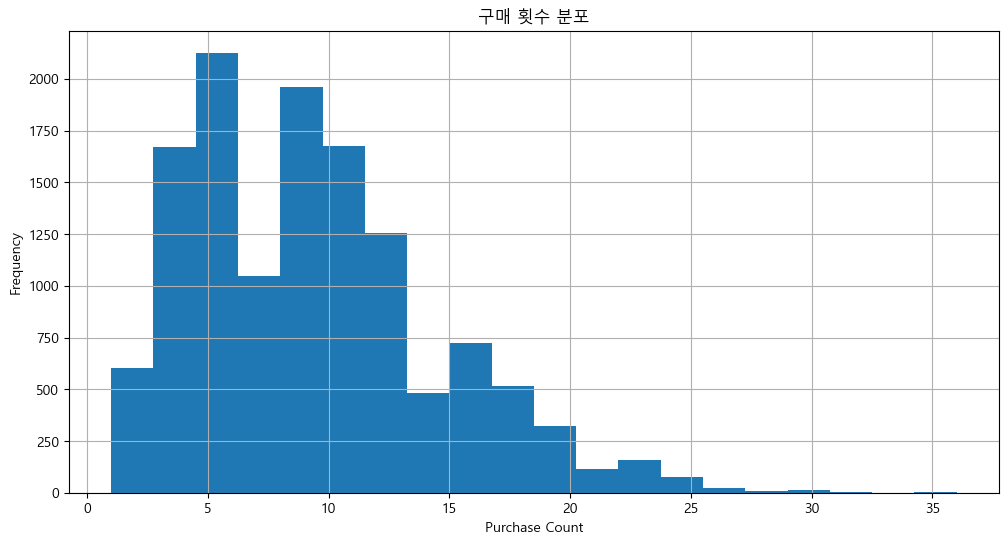

In [30]:
plt.figure()
rfm['purchase_count'].hist(bins=20)
plt.title('구매 횟수 분포')
plt.xlabel('Purchase Count')
plt.ylabel('Frequency')
plt.show()

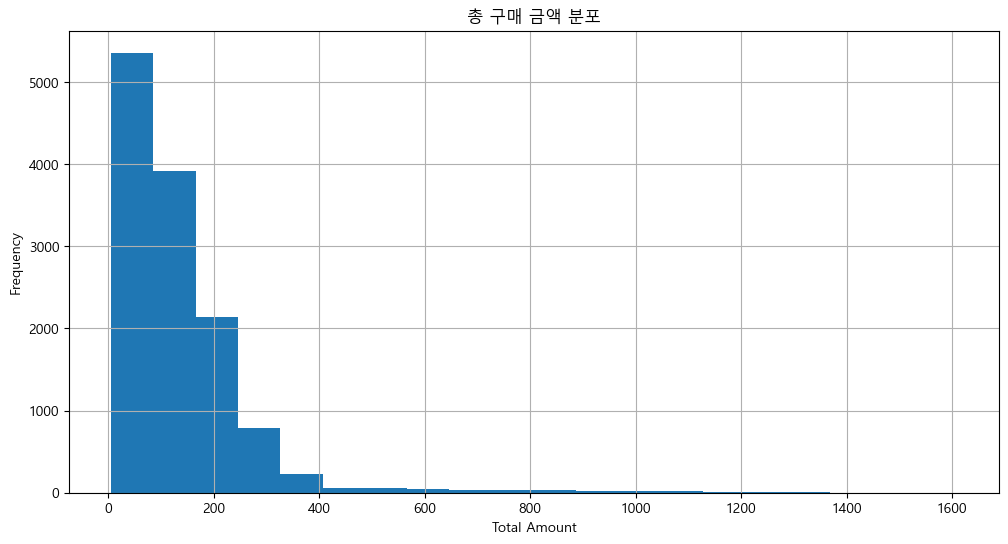

In [31]:
plt.figure()
rfm['total_amount'].hist(bins=20)
plt.title('총 구매 금액 분포')
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.show()

In [32]:
# 오퍼 이후 구매만 필터링
merged = converted_rc.merge(
    transactions,
    on='customer_id',
    how='left'
)

# received 이후 구매만
merged = merged[
    merged['time'] >= merged['time_received']
]

rfm_offer = (
    merged.groupby('customer_id')
    .agg(
        purchase_count=('amount', 'count'),
        total_amount=('amount', 'sum')
    )
    .reset_index()
)

In [37]:
converted_rc = rc[rc['converted_final'] == 1].copy()

transactions = df[df['event'] == 'transaction'][
    ['customer_id', 'time', 'amount']
].copy()

In [38]:
merged = converted_rc.merge(
    transactions,
    on='customer_id',
    how='left'
)

In [39]:
merged['period'] = np.where(
    merged['time'] < merged['time_received'],
    'before',
    'after'
)

In [41]:
compare = (
    merged.groupby(['customer_id', 'period'])
    .agg(
        purchase_count=('amount', 'count'),
        total_amount=('amount', 'sum')
    )
    .reset_index()
)

In [42]:
compare_pivot = compare.pivot(
    index='customer_id',
    columns='period',
    values=['purchase_count', 'total_amount']
).fillna(0)

compare_pivot.columns = [
    f"{col[0]}_{col[1]}" for col in compare_pivot.columns
]

compare_pivot = compare_pivot.reset_index()

In [43]:
compare_pivot['count_diff'] = (
    compare_pivot['purchase_count_after'] -
    compare_pivot['purchase_count_before']
)

compare_pivot['amount_diff'] = (
    compare_pivot['total_amount_after'] -
    compare_pivot['total_amount_before']
)

In [44]:
print("평균 구매횟수 변화:", compare_pivot['count_diff'].mean())
print("평균 구매금액 변화:", compare_pivot['amount_diff'].mean())

평균 구매횟수 변화: 5.5496320651323
평균 구매금액 변화: 96.37267574761235


In [51]:
merged['before_flag'] = (
    (merged['time'] >= merged['time_received'] - 7*24) &
    (merged['time'] < merged['time_received'])
)

merged['after_flag'] = (
    (merged['time'] >= merged['time_received']) &
    (merged['time'] <= merged['time_received'] + 7*24)
)

In [46]:
before = merged[merged['before_flag']]
after = merged[merged['after_flag']]

before_agg = before.groupby('customer_id').agg(
    before_count=('amount', 'count'),
    before_amount=('amount', 'sum')
)

after_agg = after.groupby('customer_id').agg(
    after_count=('amount', 'count'),
    after_amount=('amount', 'sum')
)

compare_final = before_agg.join(after_agg, how='outer').fillna(0)

compare_final['count_diff'] = compare_final['after_count'] - compare_final['before_count']
compare_final['amount_diff'] = compare_final['after_amount'] - compare_final['before_amount']

In [52]:
before = merged[merged['before_flag']]
after = merged[merged['after_flag']]

before_agg = before.groupby('customer_id').agg(
    before_count=('amount', 'count'),
    before_amount=('amount', 'sum')
)

after_agg = after.groupby('customer_id').agg(
    after_count=('amount', 'count'),
    after_amount=('amount', 'sum')
)

In [53]:
compare_final = before_agg.join(after_agg, how='outer').fillna(0)

In [54]:
print("=" * 80)
print("전 / 후 평균 비교")
print("=" * 80)

print("▶ 구매 횟수")
print("Before 평균:", compare_final['before_count'].mean())
print("After 평균:", compare_final['after_count'].mean())

print("\n▶ 구매 금액")
print("Before 평균:", compare_final['before_amount'].mean())
print("After 평균:", compare_final['after_amount'].mean())

전 / 후 평균 비교
▶ 구매 횟수
Before 평균: 4.650176401411211
After 평균: 7.923559388475108

▶ 구매 금액
Before 평균: 75.29571070168562
After 평균: 131.0880227361819
